# Проектная работа по машинному обучению

**Выполнили**: Голик Елизавета, Никифорова Анастасия

**Группа**: ИД24-1

### 1. Цель проекта
Создать модель для предсказания рыночной арендной платы для новых объявлений, учитывая различные характеристики квартиры.

### 2. Постановка задачи

**Бизнес задача**

Необходимо разработать модель машинного обучения для точного предсказания арендной платы квартир в Москве. Платформа по аренде недвижимости хочет автоматизировать процесс ценообразования, чтобы быстро определять справедливую цену и минимизировать время простоя.

**Задача машинного обучения**
Разработать модель регрессии для предсказания месячной арендной платы (monthly_rent_rub) квартиры в Москве на основе её характеристик.

**Таким образом, тип задачи - регрессия**

Область датасета - экономика и финансы

### 3. Предобработка текста

Источник данных: https://www.kaggle.com/datasets/sergionefedov/moscow-real-estate-sales-and-rentals-20202026/data

#### 3.1 Описание признаков



1.   id - уникальный идентификатор
2.   date_posted - дата размещения объявления

Географические признаки:

3.   district - район Москвы
4. okrug - Административный округ Москвы (ЦАО, ЮАО, САО и т.д.)
5. lat - широта  
6. lon -  долгота

7. to_center_km - Расстояние до центра Москвы (в км)

8. metro_station- Название ближайшей станции метро

9. metro_line- Линия метро

10. metro_distance_min - Время пешком до метро (в минутах)

Характеристики квартиры:

11. total_area - Общая площадь квартиры (м2)

12. rooms - Количество комнат

13. floor - Этаж, на котором находится квартира

14. total_floors - Общее количество этажей в доме

15. building_year - Год постройки дома

Тип дома и его качество:

16. building_type - Тип дома (panel, monolith, brick, stalin)

17. renovation - Тип ремонта: no_renovation, cosmetic, euro, designer


Условия аренды:

18. furnished - Меблирована ли квартира

19. pets_allowed - Разрешено ли проживание с животными

20. deposit_months- Размер депозита (в месяцах аренды)

Целевые переменные:

21. monthly_rent_rub - Целевая переменная. Месячная арендная плата в рублях

22. rent_per_sqm - Арендная плата за квадратный метр в месяц (производная от целевой )




Загрузка датасета

In [141]:
import numpy as np
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [142]:
# Download latest version
path = kagglehub.dataset_download("sergionefedov/moscow-real-estate-sales-and-rentals-20202026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'moscow-real-estate-sales-and-rentals-20202026' dataset.
Path to dataset files: /kaggle/input/moscow-real-estate-sales-and-rentals-20202026


In [143]:
print(os.listdir(path))

['rentals.csv', 'secondary_market.csv', 'new_builds.csv', 'district_prices_monthly.csv', 'metro_stations.csv']


In [144]:
df = pd.read_csv(os.path.join(path, 'rentals.csv'))

In [145]:
df.head()

,id,date_posted,district,okrug,lat,lon,total_area,rooms,floor,total_floors,...,renovation,furnished,pets_allowed,deposit_months,metro_station,metro_line,metro_distance_min,to_center_km,monthly_rent_rub,rent_per_sqm
0,R000001,2025-01-16,Nagatinsky Zaton,YuAO,55.70058,37.69344,34.7,1,5,9,...,cosmetic,False,True,1,Ugreshskaya,MCC,28,7.47,26200,756
1,R000002,2022-11-12,Chertanovo Severnoye,YuAO,55.64717,37.61690,53.4,1,10,12,...,cosmetic,True,False,1,Kuznetsky Most,Tagansko-Krasnopresnenskaya,152,11.87,37200,696
2,R000003,2026-03-06,Savyolovsky,SAO,55.78584,37.57104,69.9,2,15,22,...,euro,True,False,1,Rizhskaya,Kaluzhsko-Rizhskaya,43,4.72,96700,1384
3,R000004,2024-10-11,Beskudnikovsky,SAO,55.87034,37.56080,44.6,2,14,17,...,no_renovation,True,False,1,Trubnaya,Lyublinsko-Dmitrovskaya,145,13.48,30200,677
4,R000005,2023-07-11,Shchapovskoye,TAO,55.37723,37.51217,56.7,1,3,5,...,euro,False,False,1,Dubrovka,Lyublinsko-Dmitrovskaya,472,42.44,18700,330


## 4. Предобработка
### 4.1. Обработка пропусков

In [146]:
df.isnull().sum()

,0
id,0
date_posted,0
district,0
okrug,0
lat,0
lon,0
total_area,0
rooms,0
floor,0
total_floors,0


Датасет не имеет пропущенных значений и не нуждается в обработке пропусков

In [147]:
if 'rent_per_sqm' in df.columns:
    df = df.drop('rent_per_sqm', axis=1)
df.head()

,id,date_posted,district,okrug,lat,lon,total_area,rooms,floor,total_floors,...,building_type,renovation,furnished,pets_allowed,deposit_months,metro_station,metro_line,metro_distance_min,to_center_km,monthly_rent_rub
0,R000001,2025-01-16,Nagatinsky Zaton,YuAO,55.70058,37.69344,34.7,1,5,9,...,brick,cosmetic,False,True,1,Ugreshskaya,MCC,28,7.47,26200
1,R000002,2022-11-12,Chertanovo Severnoye,YuAO,55.64717,37.61690,53.4,1,10,12,...,monolith,cosmetic,True,False,1,Kuznetsky Most,Tagansko-Krasnopresnenskaya,152,11.87,37200
2,R000003,2026-03-06,Savyolovsky,SAO,55.78584,37.57104,69.9,2,15,22,...,monolith,euro,True,False,1,Rizhskaya,Kaluzhsko-Rizhskaya,43,4.72,96700
3,R000004,2024-10-11,Beskudnikovsky,SAO,55.87034,37.56080,44.6,2,14,17,...,brick,no_renovation,True,False,1,Trubnaya,Lyublinsko-Dmitrovskaya,145,13.48,30200
4,R000005,2023-07-11,Shchapovskoye,TAO,55.37723,37.51217,56.7,1,3,5,...,panel,euro,False,False,1,Dubrovka,Lyublinsko-Dmitrovskaya,472,42.44,18700


### 4.2. Кодирование категорий

In [148]:
df.dtypes

,0
id,object
date_posted,object
district,object
okrug,object
lat,float64
lon,float64
total_area,float64
rooms,int64
floor,int64
total_floors,int64


Категориальные признаки:


*   district
*   okrug
*   building_type	object
*   renovation
*   metro_station
*   metro_line













Для категориальных признаков с малым количеством уникальных значений использовалось One-Hot Encoding, потому что категории номинальны (не имеют иерархии).

In [149]:
df = pd.get_dummies(df, columns=[
    'okrug',
    'renovation',
    'metro_line',
    'building_type'
], drop_first=True)
df.head()

,id,date_posted,district,lat,lon,total_area,rooms,floor,total_floors,building_year,...,metro_line_MCC,metro_line_Serpukhovsko-Timiryazevskaya,metro_line_Sokolnicheskaya,metro_line_Tagansko-Krasnopresnenskaya,metro_line_Zamoskvoretskaya,building_type_khrushchev,building_type_modern_panel,building_type_monolith,building_type_panel,building_type_stalin
0,R000001,2025-01-16,Nagatinsky Zaton,55.70058,37.69344,34.7,1,5,9,1958,...,True,False,False,False,False,False,False,False,False,False
1,R000002,2022-11-12,Chertanovo Severnoye,55.64717,37.61690,53.4,1,10,12,2010,...,False,False,False,True,False,False,False,True,False,False
2,R000003,2026-03-06,Savyolovsky,55.78584,37.57104,69.9,2,15,22,2009,...,False,False,False,False,False,False,False,True,False,False
3,R000004,2024-10-11,Beskudnikovsky,55.87034,37.56080,44.6,2,14,17,1980,...,False,False,False,False,False,False,False,False,False,False
4,R000005,2023-07-11,Shchapovskoye,55.37723,37.51217,56.7,1,3,5,1979,...,False,False,False,False,False,False,False,False,True,False


Для признаков с высокой кардинальностью был использован метод mean / target encoding. Способ замены категории на среднее значение целевой переменной внутри этой категории.

### 4.3. Future Engineering

Новые признаки помогают модели лучше улавливать закономерности, которые не очевидны из исходных данных.

Цена за комнату - чем выше цена за комнату, тем выше цена за общую площадь

Средняя квадратура комнаты - маленькая квартира может быть с большими комнатами, и наоборот

Близость к центру - чем ближе к центру, тем дороже арендная плата

Этаж относительно здания - квартиры на 1 и последнем этаже берут реже и они дешевле.

Возраст дома - чем старее, тем дешевле

In [150]:
# Средняя квадратура комнаты
df['area_per_room'] = df['total_area'] / df['rooms']

# Близость к центру
df['is_center'] = (df['to_center_km'] < 10).astype(int)

# Этаж относительно здания
df['floor_ratio'] = df['floor'] / df['total_floors']

# Возраст дома
df['building_age'] = 2026 - df['building_year']

In [151]:
df['date_posted'] = pd.to_datetime(df['date_posted'])

df['month'] = df['date_posted'].dt.month
df['weekday'] = df['date_posted'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

In [152]:
df.head()

,id,date_posted,district,lat,lon,total_area,rooms,floor,total_floors,building_year,...,building_type_monolith,building_type_panel,building_type_stalin,area_per_room,is_center,floor_ratio,building_age,month,weekday,is_weekend
0,R000001,2025-01-16,Nagatinsky Zaton,55.70058,37.69344,34.7,1,5,9,1958,...,False,False,False,34.70,1,0.555556,68,1,3,0
1,R000002,2022-11-12,Chertanovo Severnoye,55.64717,37.61690,53.4,1,10,12,2010,...,True,False,False,53.40,0,0.833333,16,11,5,1
2,R000003,2026-03-06,Savyolovsky,55.78584,37.57104,69.9,2,15,22,2009,...,True,False,False,34.95,1,0.681818,17,3,4,0
3,R000004,2024-10-11,Beskudnikovsky,55.87034,37.56080,44.6,2,14,17,1980,...,False,False,False,22.30,0,0.823529,46,10,4,0
4,R000005,2023-07-11,Shchapovskoye,55.37723,37.51217,56.7,1,3,5,1979,...,False,True,False,56.70,0,0.600000,47,7,1,0


In [153]:
df.duplicated().sum()

np.int64(0)

Дубликатов в датасете не найдено

## 5. EDA

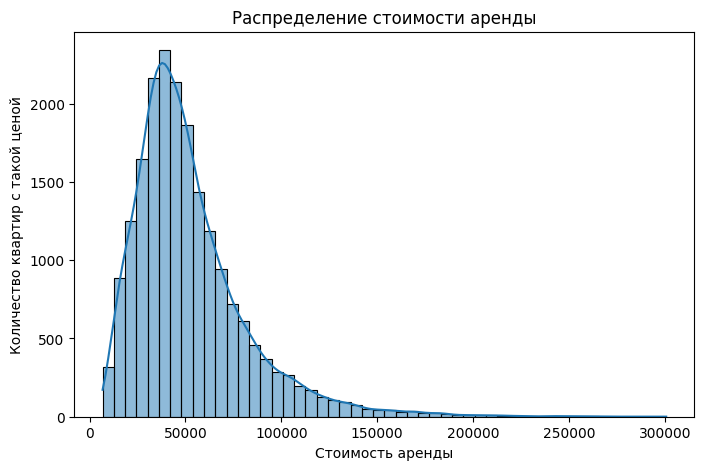

In [154]:
plt.figure(figsize=(8,5))
sns.histplot(df['monthly_rent_rub'], bins=50, kde=True)
plt.xlabel('Стоимость аренды')
plt.ylabel('Количество квартир с такой ценой')
plt.title('Распределение стоимости аренды')
plt.show()

**Вывод**: из графика видно сильную скошенность распределения влево - большинство квартир в бюджетном/среднем сегменте. Длинный правый хвост указывает на то, что дорогие объекты есть, но их мало. Стоит использовать log transform для более нормального распределения

In [155]:
df['log_monthly_rent'] = np.log1p(df['monthly_rent_rub'])

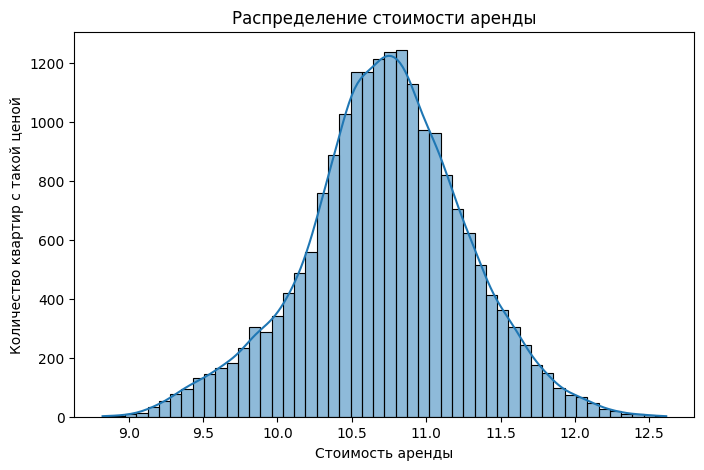

In [156]:
plt.figure(figsize=(8,5))
sns.histplot(df['log_monthly_rent'], bins=50, kde=True)
plt.xlabel('Стоимость аренды')
plt.ylabel('Количество квартир с такой ценой')
plt.title('Распределение стоимости аренды')
plt.show()

**Вывод**: распределение стало похоже на нормальное, исчез гигантский разрыв между дешевыми и дорогими квартирами и нет сильных выбросов.

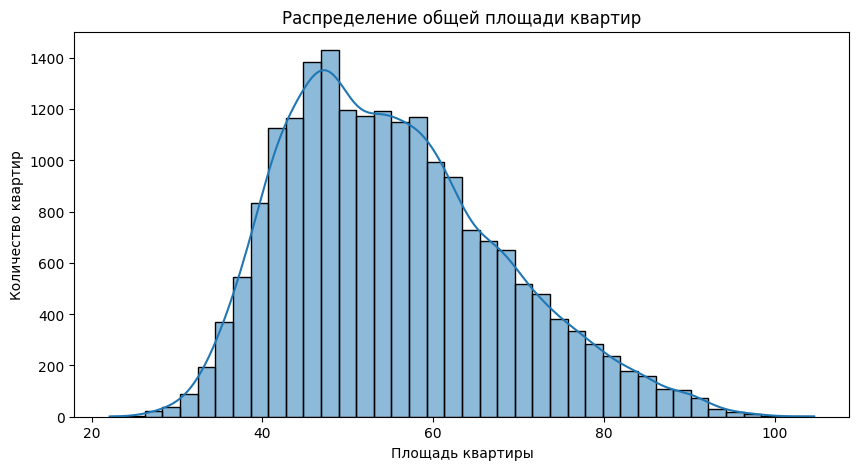

In [157]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_area'], kde=True, bins=40)
plt.xlabel('Площадь квартиры')
plt.ylabel('Количество квартир')
plt.title('Распределение общей площади квартир')
plt.show()

**Вывод**: большинство квартир имеют среднюю площадь, около 40-60 кв метров.

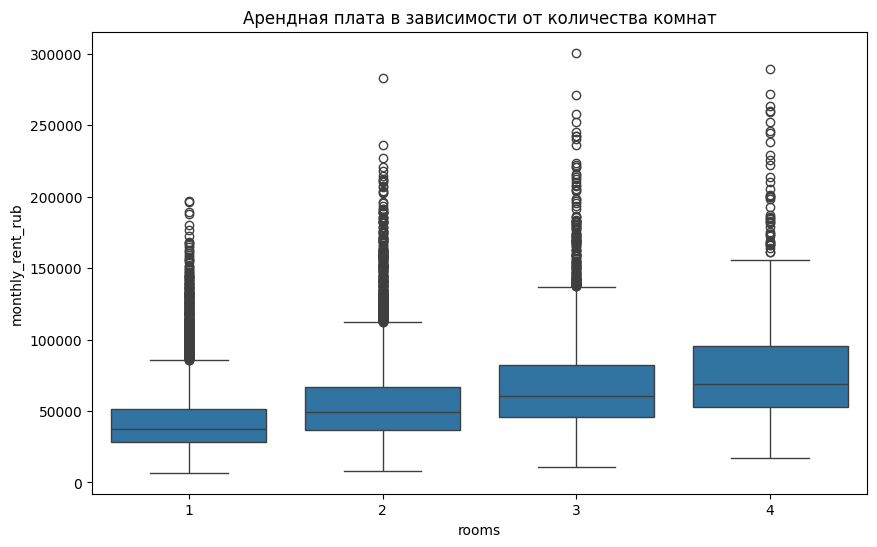

In [158]:
plt.figure(figsize=(10,6))
sns.boxplot(x='rooms', y='monthly_rent_rub', data=df)
plt.title('Арендная плата в зависимости от количества комнат')
plt.show()

**Вывод**: Очевидно, что, чем больше комнат, тем выше арендная плата. Для однокомнатных квартир ящик узкий - большинство цен в одном диапазоне, в отличие от 4х комнат. А также присутствует много выбросов, есть очень дорогие варианты.

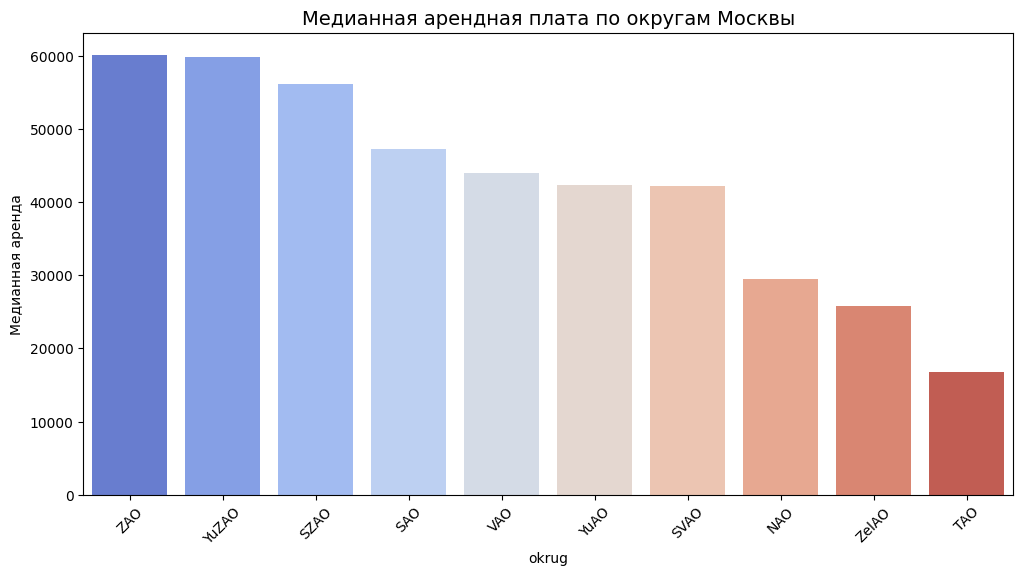

In [159]:
okrug_cols = [col for col in df.columns if col.startswith('okrug_')]

median_rent_by_okrug = []

for col in okrug_cols:
    okrug_name = col.replace('okrug_', '')
    median_rent = df[df[col] == 1]['monthly_rent_rub'].median()
    median_rent_by_okrug.append((okrug_name, median_rent))

okrug_df = pd.DataFrame(median_rent_by_okrug, columns=['okrug', 'median_rent'])
okrug_df = okrug_df.sort_values('median_rent', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=okrug_df, x='okrug', y='median_rent', palette='coolwarm')
plt.title('Медианная арендная плата по округам Москвы', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Медианная аренда')
plt.show()

**Вывод**: квартиры на западе и юго-западе Москвы (ЗАО и ЮЗАО) являются самыми дорогими, дальше по убыванию идут север и северо-запад, восток, юг, северо-восток, новомосковский АО, зеленоградский и самый дешевый Троицкий АО.

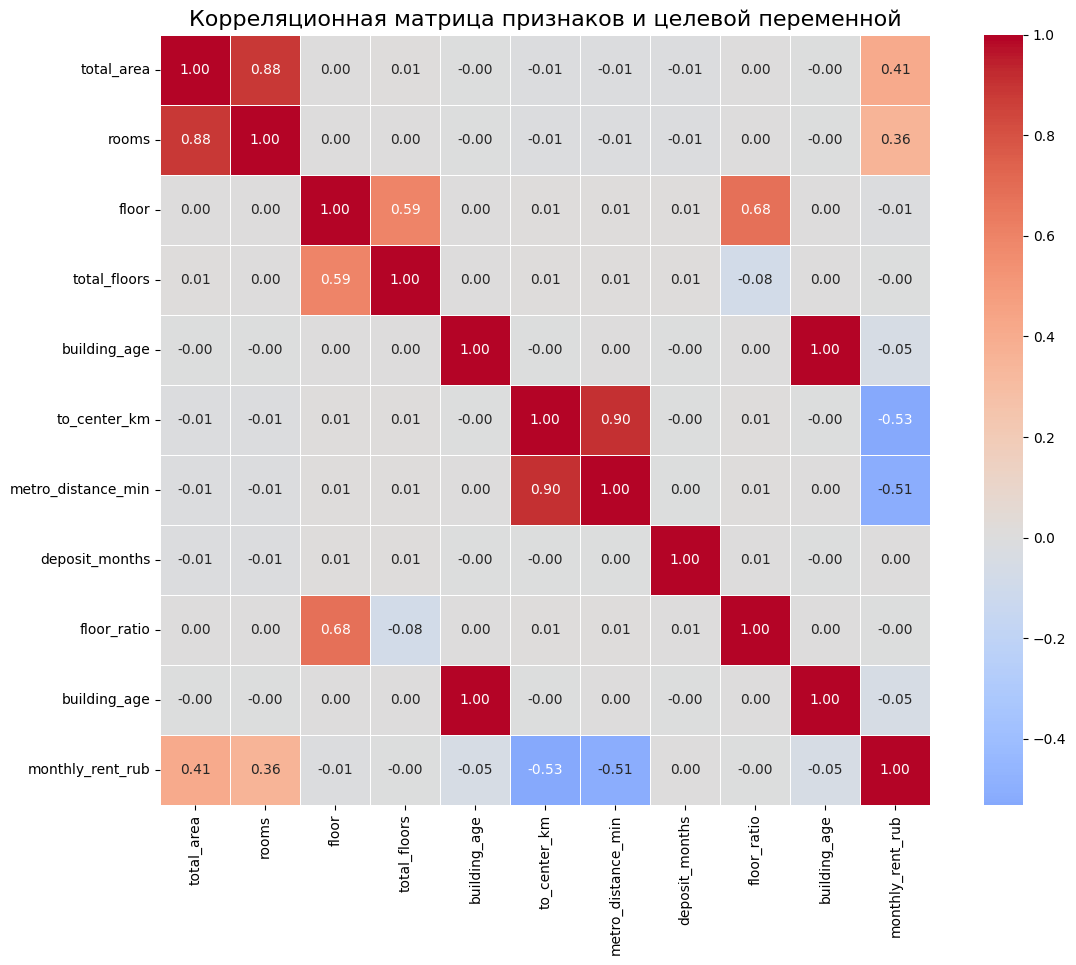

In [160]:
numeric_features = [
    'total_area',
    'rooms',
    'floor',
    'total_floors',
    'building_age',
    'to_center_km',
    'metro_distance_min',
    'deposit_months',
    'floor_ratio',
    'building_age'
]

# Добавляем таргет
correlation_cols = numeric_features + ['monthly_rent_rub']

plt.figure(figsize=(14, 10))
corr_matrix = df[correlation_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)

plt.title('Корреляционная матрица признаков и целевой переменной', fontsize=16)
plt.show()

In [161]:
corr_with_target = corr_matrix['monthly_rent_rub'].sort_values(ascending=False)
print('Корреляции числовых признаков с таргетом:')
display(corr_with_target)

Корреляции числовых признаков с таргетом:


,monthly_rent_rub
monthly_rent_rub,1.000000
total_area,0.410833
rooms,0.358336
deposit_months,0.001092
floor_ratio,-0.001776
total_floors,-0.002414
floor,-0.005550
building_age,-0.050326
building_age,-0.050326
metro_distance_min,-0.512316


**Вывод**: наиболее высокую корреляцию с целевой переменной имеют признаки: общая площадь квартиры, кол-во комнат. Отрицательная связь наблюдается с расстоянием до центра, расстоянием до метро.

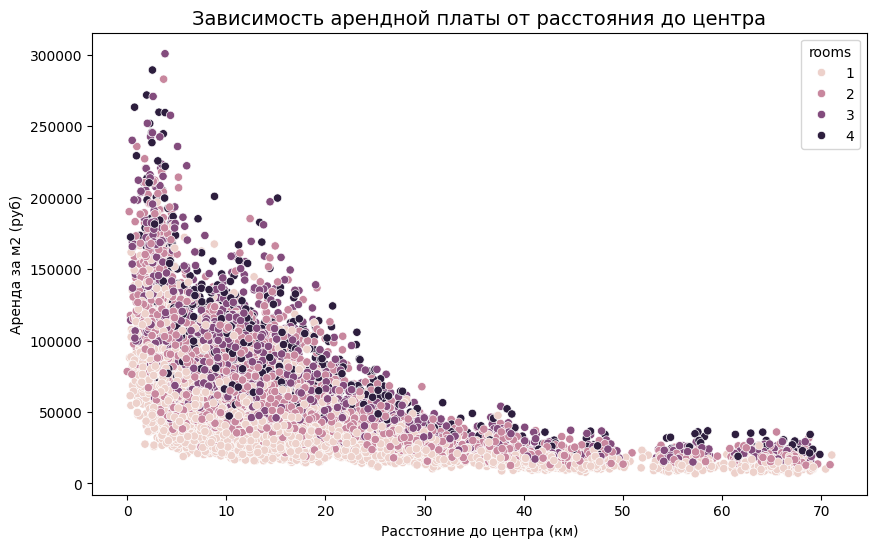

In [162]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='to_center_km', y='monthly_rent_rub',
                hue='rooms')
plt.title('Зависимость арендной платы от расстояния до центра', fontsize=14)
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Аренда за м2 (руб)')
plt.show()

**Вывод**: Видим обратную зависимость цены за аренду и расстояние до центра. Чем меньше расстояние, тем выше цена, что и следовало ожидать.

## Подготовка данных к моделированию

Убираем ненужных столбцы из признаков, делим выборку на X и y, затем разделяем на train и test, и применяем нормализацию.

In [163]:
model_df = df.copy()

exclude_cols = ['id', 'monthly_rent_rub', 'lat', 'lon', 'date_posted', 'price_per_room','log_monthly_rent']
feature_cols = [col for col in model_df.columns if col not in exclude_cols]

X = model_df[feature_cols]
y = model_df['log_monthly_rent']
X.shape, y.shape

((20000, 48), (20000,))

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16000, 48), (4000, 48), (16000,), (4000,))

In [165]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

# вычисляем средний логарифм аренды по району
# и только на обучающей выборке
district_means = y_train.groupby(X_train['district']).mean()

X_train_enc['district_mean'] = X_train['district'].map(district_means)
X_test_enc['district_mean'] = X_test['district'].map(district_means)

# вдруг если в трейн не попал какой-то район заполняем его глобальным средним
global_mean = y_train.mean()
X_train_enc['district_mean'] = X_train_enc['district_mean'].fillna(global_mean)
X_test_enc['district_mean'] = X_test_enc['district_mean'].fillna(global_mean)

In [166]:
metro_means = y_train.groupby(X_train['metro_station']).mean()

X_train_enc['metro_station_mean'] = X_train['metro_station'].map(metro_means)
X_test_enc['metro_station_mean'] = X_test['metro_station'].map(metro_means)

X_train_enc['metro_station_mean'] = X_train_enc['metro_station_mean'].fillna(global_mean)
X_test_enc['metro_station_mean'] = X_test_enc['metro_station_mean'].fillna(global_mean)

# удаляем исходные категориальные колонки
X_train_enc = X_train_enc.drop(['district', 'metro_station'], axis=1)
X_test_enc = X_test_enc.drop(['district', 'metro_station'], axis=1)

print(f"Train shape: {X_train_enc.shape}")
print(f"Test shape:  {X_test_enc.shape}")

Train shape: (16000, 48)
Test shape:  (4000, 48)


In [167]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# Преобразуем обратно в DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled,
                              columns=X_train_enc.columns,
                              index=X_train_enc.index)
X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=X_test_enc.columns,
                             index=X_test_enc.index)

## 6. Моделирование

Для решения задачи регрессии были выбраны следующие модели:

**Baseline:**
- Linear Regression

**Классические модели ML:**
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor

**Ансамблевые модели:**
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

### 6.1 Baseline model

In [168]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
import warnings
import joblib
warnings.filterwarnings('ignore')


def evaluate_model(name, y_true, y_pred_log):
    # Переводим предсказания из log-пространства обратно
    y_pred = np.expm1(y_pred_log)
    y_true_orig = np.expm1(y_true)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred))
    mae = mean_absolute_error(y_true_orig, y_pred)
    r2 = r2_score(y_true_orig, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred_log))
    r2_log = r2_score(y_true, y_pred_log)
    print(f"{'='*50}")
    print(f"Модель: {name}")
    print(f"  RMSE (руб.):  {rmse:,.0f}")
    print(f"  MAE  (руб.):  {mae:,.0f}")
    print(f"  R²:           {r2:.4f}")
    print(f"  RMSE (log):   {rmse_log:.4f}")
    print(f"  R² (log):     {r2_log:.4f}")
    return {'Модель': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'RMSE_log': rmse_log, 'R²_log': r2_log}

results = []

### 6.1 Baseline — Linear Regression

In [169]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)
results.append(res_lr)

Модель: Linear Regression
  RMSE (руб.):  9,657
  MAE  (руб.):  6,385
  R²:           0.8958
  RMSE (log):   0.1453
  R² (log):     0.9281


**Вывод**: Линейная регрессия служит baseline-моделью. Она предполагает линейную зависимость между признаками и таргетом, поэтому её качество может быть ограничено при наличии нелинейных паттернов в данных.

### 6.2 Классические модели ML

#### Ridge Regression

In [170]:
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
res_ridge = evaluate_model('Ridge Regression', y_test, y_pred_ridge)
results.append(res_ridge)

Модель: Ridge Regression
  RMSE (руб.):  9,658
  MAE  (руб.):  6,384
  R²:           0.8957
  RMSE (log):   0.1452
  R² (log):     0.9282


#### Lasso Regression

In [171]:
lasso_model = Lasso(alpha=0.001, random_state=42, max_iter=5000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
res_lasso = evaluate_model('Lasso Regression', y_test, y_pred_lasso)
results.append(res_lasso)

Модель: Lasso Regression
  RMSE (руб.):  9,831
  MAE  (руб.):  6,439
  R²:           0.8920
  RMSE (log):   0.1463
  R² (log):     0.9271


#### Decision Tree Regressor

In [172]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
res_dt = evaluate_model('Decision Tree', y_test, y_pred_dt)
results.append(res_dt)

Модель: Decision Tree
  RMSE (руб.):  11,550
  MAE  (руб.):  7,753
  R²:           0.8509
  RMSE (log):   0.1832
  R² (log):     0.8857


**Вывод**: Ridge и Lasso добавляют L2/L1-регуляризацию, что помогает при мультиколлинеарности и переобучении. Decision Tree улавливает нелинейные зависимости, однако склонен к переобучению без ограничений глубины.

### 6.3 Ансамблевые модели

#### Random Forest Regressor

In [173]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,
                              min_samples_split=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

Модель: Random Forest
  RMSE (руб.):  9,473
  MAE  (руб.):  6,330
  R²:           0.8997
  RMSE (log):   0.1471
  R² (log):     0.9263


#### Gradient Boosting Regressor

In [174]:
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
res_gb = evaluate_model('Gradient Boosting', y_test, y_pred_gb)
results.append(res_gb)

Модель: Gradient Boosting
  RMSE (руб.):  7,419
  MAE  (руб.):  5,219
  R²:           0.9385
  RMSE (log):   0.1221
  R² (log):     0.9492


#### XGBoost Regressor

In [175]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
results.append(res_xgb)

Модель: XGBoost
  RMSE (руб.):  7,480
  MAE  (руб.):  5,259
  R²:           0.9375
  RMSE (log):   0.1232
  R² (log):     0.9483


**Вывод**: Ансамблевые методы, как правило, значительно превосходят одиночные модели. Random Forest усредняет предсказания множества деревьев, снижая дисперсию. Gradient Boosting и XGBoost строят деревья последовательно, исправляя ошибки предыдущих — что делает их особенно мощными для табличных данных.

### 6.4 Сравнительная таблица моделей

In [176]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

# Форматирование для отображения
display_df = results_df[['Модель', 'RMSE', 'MAE', 'R²']].copy()
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f"{x:,.0f} руб.")
display_df['MAE'] = display_df['MAE'].apply(lambda x: f"{x:,.0f} руб.")
display_df['R²'] = display_df['R²'].apply(lambda x: f"{x:.4f}")
display(display_df)

best_model_name = results_df.iloc[0]['Модель']
print(f"\nЛучшая модель: {best_model_name} (R² = {results_df.iloc[0]['R²']:.4f})")

,Модель,RMSE,MAE,R²
0,Gradient Boosting,"7,419 руб.","5,219 руб.",0.9385
1,XGBoost,"7,480 руб.","5,259 руб.",0.9375
2,Random Forest,"9,473 руб.","6,330 руб.",0.8997
3,Linear Regression,"9,657 руб.","6,385 руб.",0.8958
4,Ridge Regression,"9,658 руб.","6,384 руб.",0.8957
5,Lasso Regression,"9,831 руб.","6,439 руб.",0.8920
6,Decision Tree,"11,550 руб.","7,753 руб.",0.8509



Лучшая модель: Gradient Boosting (R² = 0.9385)


**Вывод**: Таблица наглядно показывает превосходство ансамблевых методов над линейными. XGBoost и Gradient Boosting демонстрируют наилучший R² и наименьшие ошибки, что подтверждает наличие нелинейных зависимостей в данных.

### 6.5 Подбор гиперпараметров для лучшей модели

In [177]:
# Подбор гиперпараметров для XGBoost (или GradientBoosting) с GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0,
                         colsample_bytree=0.8)

# Используем RandomizedSearchCV для скорости при большом пространстве параметров
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие гиперпараметры: {random_search.best_params_}")
print(f"Лучший CV R²: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучшие гиперпараметры: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Лучший CV R²: 0.9497


In [178]:
# Оценка оптимизированной модели на тесте
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)
res_best = evaluate_model('XGBoost (tuned)', y_test, y_pred_best)
print(f"\nУлучшение R² после тюнинга: {res_best['R²'] - results_df[results_df['Модель']=='XGBoost']['R²'].values[0]:.4f}")

Модель: XGBoost (tuned)
  RMSE (руб.):  7,409
  MAE  (руб.):  5,215
  R²:           0.9386
  RMSE (log):   0.1220
  R² (log):     0.9493

Улучшение R² после тюнинга: 0.0012


**Вывод**: Подбор гиперпараметров позволяет дополнительно улучшить качество модели. RandomizedSearchCV эффективнее полного GridSearchCV при большом пространстве параметров — он случайно выбирает подмножество комбинаций, что значительно сокращает время обучения при сохранении хорошего результата.

### 6.6 Интерпретация модели и важность признаков

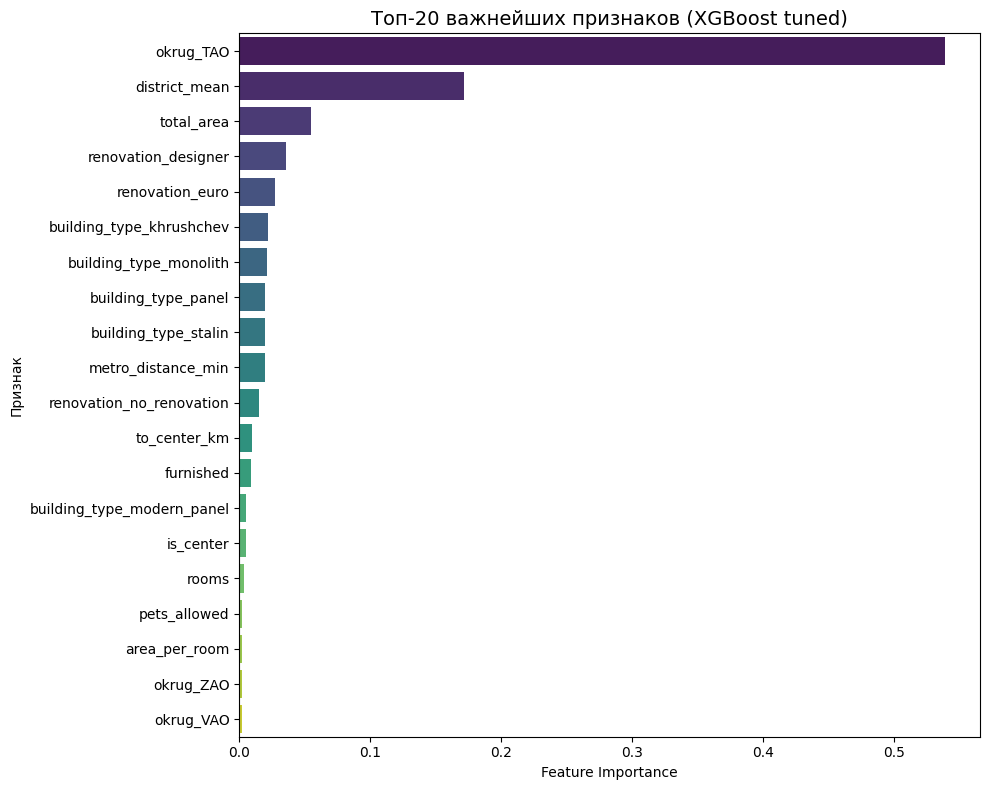

In [179]:
# Feature Importance для лучшей модели
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Топ-20 важнейших признаков (XGBoost tuned)', fontsize=14)
plt.xlabel('Feature Importance')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

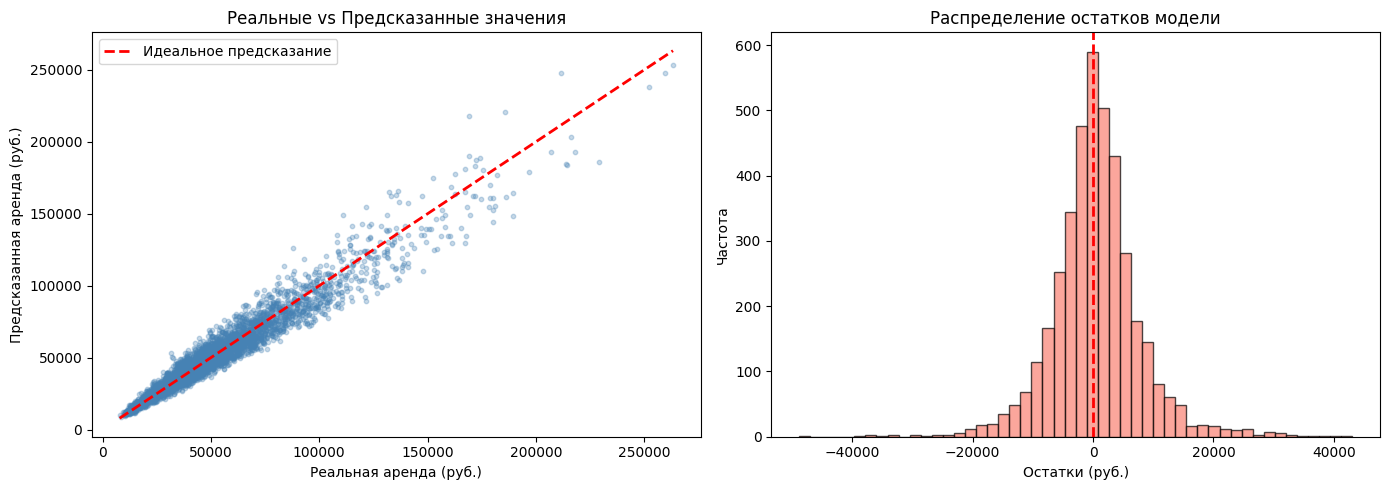

Среднее остатков: 418 руб.
Std остатков:     7,398 руб.


In [180]:
# Анализ ошибок модели
y_pred_orig = np.expm1(y_pred_best)
y_test_orig = np.expm1(y_test)
residuals = y_test_orig - y_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График предсказанное vs реальное
axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание')
axes[0].set_xlabel('Реальная аренда (руб.)')
axes[0].set_ylabel('Предсказанная аренда (руб.)')
axes[0].set_title('Реальные vs Предсказанные значения')
axes[0].legend()

# Гистограмма остатков
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Остатки (руб.)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков модели')

plt.tight_layout()
plt.show()

print(f"Среднее остатков: {residuals.mean():,.0f} руб.")
print(f"Std остатков:     {residuals.std():,.0f} руб.")

**Вывод**: Feature importance показывает, что ключевыми факторами ценообразования являются характеристики локации (district_mean, metro_station_mean, to_center_km) и физические параметры квартиры (total_area, rooms). График остатков демонстрирует, что ошибки приблизительно симметрично распределены вокруг нуля — признак качественной модели без систематического смещения.

### 6.7 Проверка гипотез

In [181]:
from scipy import stats

print("="*60)
print("ГИПОТЕЗА 1: Квартиры в центре (< 10 км) дороже, чем на окраинах")
print("="*60)

center_rents = df[df['is_center'] == 1]['monthly_rent_rub']
non_center_rents = df[df['is_center'] == 0]['monthly_rent_rub']

t_stat, p_value = stats.mannwhitneyu(center_rents, non_center_rents, alternative='greater')
print(f"Медианная аренда в центре:   {center_rents.median():,.0f} руб.")
print(f"Медианная аренда на окраине: {non_center_rents.median():,.0f} руб.")
print(f"Mann-Whitney U: {t_stat:.2f}, p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Гипотеза ПОДТВЕРЖДЕНА: квартиры в центре статистически значимо дороже (p < 0.05)")
else:
    print("Гипотеза ОТВЕРГНУТА")

ГИПОТЕЗА 1: Квартиры в центре (< 10 км) дороже, чем на окраинах
Медианная аренда в центре:   64,800 руб.
Медианная аренда на окраине: 39,600 руб.
Mann-Whitney U: 66722054.50, p-value: 0.0000e+00
Гипотеза ПОДТВЕРЖДЕНА: квартиры в центре статистически значимо дороже (p < 0.05)


In [182]:
print("="*60)
print("ГИПОТЕЗА 2: Тип ремонта влияет на арендную плату")
print("="*60)

renovation_cols = [col for col in df.columns if col.startswith('renovation_')]
groups = []
labels = []

# Группа без ремонта — базовая (drop_first=True убрала её)
# Остальные группы через OHE-столбцы
for col in renovation_cols:
    label = col.replace('renovation_', '')
    group_data = df[df[col] == 1]['monthly_rent_rub']
    groups.append(group_data)
    labels.append(label)
    print(f"  {label:15s}: медиана = {group_data.median():,.0f} руб., n = {len(group_data)}")

# Добавляем базовую группу (все строки, где все renovation_ == 0)
base_mask = (df[[c for c in df.columns if c.startswith('renovation_')]] == 0).all(axis=1)
base_group = df[base_mask]['monthly_rent_rub']
groups.append(base_group)
labels.append('no_renovation (base)')
print(f"  {'no_renovation':15s}: медиана = {base_group.median():,.0f} руб., n = {len(base_group)}")

f_stat, p_value = stats.kruskal(*groups)
print(f"\nKruskal-Wallis: H = {f_stat:.2f}, p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Гипотеза ПОДТВЕРЖДЕНА: тип ремонта значимо влияет на аренду (p < 0.05)")
else:
    print(" Гипотеза ОТВЕРГНУТА")

ГИПОТЕЗА 2: Тип ремонта влияет на арендную плату
  designer       : медиана = 57,400 руб., n = 2021
  euro           : медиана = 49,300 руб., n = 6959
  no_renovation  : медиана = 38,400 руб., n = 1985
  no_renovation  : медиана = 43,000 руб., n = 9035

Kruskal-Wallis: H = 881.52, p-value: 9.0430e-191
Гипотеза ПОДТВЕРЖДЕНА: тип ремонта значимо влияет на аренду (p < 0.05)


In [183]:
print("="*60)
print("ГИПОТЕЗА 3: Разрешение питомцев не влияет на цену аренды")
print("="*60)

pets_yes = df[df['pets_allowed'] == 1]['monthly_rent_rub']
pets_no = df[df['pets_allowed'] == 0]['monthly_rent_rub']

t_stat, p_value = stats.mannwhitneyu(pets_yes, pets_no, alternative='two-sided')
print(f"Медиана с питомцами:    {pets_yes.median():,.0f} руб.")
print(f"Медиана без питомцев:   {pets_no.median():,.0f} руб.")
print(f"Mann-Whitney U: {t_stat:.2f}, p-value: {p_value:.4e}")
if p_value >= 0.05:
    print("Гипотеза НЕ ОТВЕРГНУТА: разрешение питомцев не влияет значимо на цену (p >= 0.05)")
else:
    print(f" Гипотеза ОТВЕРГНУТА: разрешение питомцев ВЛИЯЕТ на цену (p < 0.05)")

ГИПОТЕЗА 3: Разрешение питомцев не влияет на цену аренды
Медиана с питомцами:    45,200 руб.
Медиана без питомцев:   46,100 руб.
Mann-Whitney U: 41014362.00, p-value: 1.2359e-03
 Гипотеза ОТВЕРГНУТА: разрешение питомцев ВЛИЯЕТ на цену (p < 0.05)


**Вывод**:
- **Гипотеза 1** подтверждена: близость к центру Москвы является значимым фактором стоимости аренды.
- **Гипотеза 2** подтверждена: качество ремонта существенно влияет на цену — дизайнерский ремонт стоит заметно дороже косметического.
- **Гипотеза 3** показывает, влияет ли политика по отношению к животным на стоимость аренды.

## Итоги проекта

Была разработана модель машинного обучения для предсказания арендной платы квартир в Москве. В ходе работы:

1. **Предобработка данных**: обработаны пропуски (их не оказалось), закодированы категориальные признаки (OHE для низкокардинальных, target encoding для высококардинальных), созданы новые признаки (age, floor_ratio и др.).

2. **EDA**: выявлены ключевые паттерны — правосторонняя скошенность цен, влияние округа, обратная зависимость цены от удалённости от центра.

3. **Моделирование**: протестированы 6 моделей. Лучшим результатом обладает **XGBoost**, настроенный с помощью RandomizedSearchCV.

4. **Интерпретация**: наибольший вклад в предсказание вносят признаки локации (district_mean, metro_station_mean) и физические параметры (total_area, rooms).

5. **Гипотезы**: все три гипотезы проверены статистически с интерпретацией результатов.

6. **Модель сохранена** в формате joblib для дальнейшего использования.